# CIO Assignment - Getting Started Notebook
## CT099-3-M - Computational Intelligence and Optimisation

**This notebook runs during today's orientation session.**
Follow along with the slides. Each part takes about 5-10 minutes.

---

### Before you open this notebook

**Step 1 - Open the skeleton in VS Code:**
File -> Open Folder -> select the `cio_skeleton` folder

**Step 2 - Open a Terminal inside VS Code:**
Menu -> Terminal -> New Terminal
(It opens at the bottom, already inside the cio_skeleton folder)

**Step 3 - Install dependencies** (once only):
```
pip install -r requirements.txt
```

**Step 4 - Fix the Python path** (once only):
```
echo PYTHONPATH=. > .env
```
This creates a `.env` file so VS Code finds the `cio` package.
Verify: `PYTHONPATH=. pytest tests/ -q` should say 49 passed.

**Step 5 - Run your first experiment** (paste into the VS Code Terminal):
```
python scripts/run.py --config configs/nsga2_baseline.yaml \
    --instance instances/ot_small.json \
    --out results/first_run/ --n-runs 3 --n-generations 20 --quiet
```
When done, `results/first_run/` appears in the VS Code Explorer panel on the left.

**Step 6 - Open this notebook:**
In the VS Code Explorer, click `CIO_GettingStarted.ipynb`.
Select your Python interpreter in the top-right corner if prompted.
Install the Jupyter extension if VS Code asks for it.

---


## Setup - run this first

In [2]:
# Plots display inline automatically in VS Code Jupyter.
# If you see no plots, uncomment the line below:
# %matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import json, glob, os, sys, time

# Path setup - finds the cio package whether you are at the skeleton root or a subfolder
if os.path.exists('cio'):
    sys.path.insert(0, '.')
elif os.path.exists('../cio'):
    sys.path.insert(0, '..')
else:
    print('WARNING: Cannot find the cio package.')
    print('Fix: In VS Code, File -> Open Folder -> select the cio_skeleton folder')
    print('     Then reopen this notebook from the Explorer panel on the left')

TEAL, PURPLE, AMBER, RED = '#028090', '#6B4FA0', '#E8A020', '#C0392B'

print('Working directory:', os.getcwd())
cio_found = any(p in ('.', os.getcwd()) for p in sys.path[:5])
print('cio package reachable:', cio_found)

if not cio_found:
    print()
    print('If the above says False: close this notebook, open VS Code from')
    print('the cio_skeleton folder, then reopen the notebook.')


Working directory: c:\Users\masri\OneDrive - Asia Pacific University of Technology And Innovation (APU)\SEM 2\CIO\2-cio_assignmentMaterial\cio_skeleton
cio package reachable: True


---
## Part 1 - Load your first result and understand it

After running the experiment in the VS Code Terminal, a `results/first_run/` folder
should appear in the Explorer panel on the left.

The cell below loads one of those JSON files from Python.
You can also click any `run_*.json` file in the Explorer to view the raw JSON directly.


In [12]:
result_files = sorted(glob.glob('results/nsga2_small/run_*.json'))

if not result_files:
    print('No results found. Run the command at the top of this notebook first.')
else:
    print(f'Found {len(result_files)} result file(s)')
    with open(result_files[0]) as f:
        run = json.load(f)

    F = np.array(run['F'])   # The Pareto front
    print(f'Config:   {run["config_name"]}')
    print(f'Instance: {run["instance_name"]}')
    print(f'Runtime:  {run["runtime_seconds"]:.1f}s')
    print()
    print(f'Pareto front: {F.shape[0]} solutions x {F.shape[1]} objectives')
    print()
    print('First 5 solutions [f1, f2, f3]:')
    print('  f1 = negative throughput  (more negative = MORE surgeries scheduled)')
    print('  f2 = resource imbalance   (lower = better)')
    print('  f3 = waiting-time fairness (lower = better)')
    print()
    for i, row in enumerate(F[:5]):
        print(f'  {i+1}: f1={row[0]:7.1f}  f2={row[1]:7.1f}  f3={row[2]:.4f}')


Found 3 result file(s)
Config:   nsga2_baseline
Instance: small
Runtime:  7.1s

Pareto front: 100 solutions x 3 objectives

First 5 solutions [f1, f2, f3]:
  f1 = negative throughput  (more negative = MORE surgeries scheduled)
  f2 = resource imbalance   (lower = better)
  f3 = waiting-time fairness (lower = better)

  1: f1=   13.0  f2=   41.5  f3=3.2916
  2: f1=  133.0  f2=   41.5  f3=0.5224
  3: f1=  107.0  f2=  165.8  f3=0.0134
  4: f1=  -32.0  f2=   67.8  f3=1.4725
  5: f1=   13.0  f2=   41.5  f3=3.2916


### What you are seeing

- **f1 = -68** means the algorithm scheduled 68 priority-points of surgery. More negative = better.
- **f2 = 95** means there is imbalance in resource usage. Lower is better.
- **f3 = 0.012** means waiting times are fairly similar across priority groups. Lower is better.

Each row is one schedule on the Pareto front. No row dominates any other row.


---
## Part 2 - Plot your Pareto front

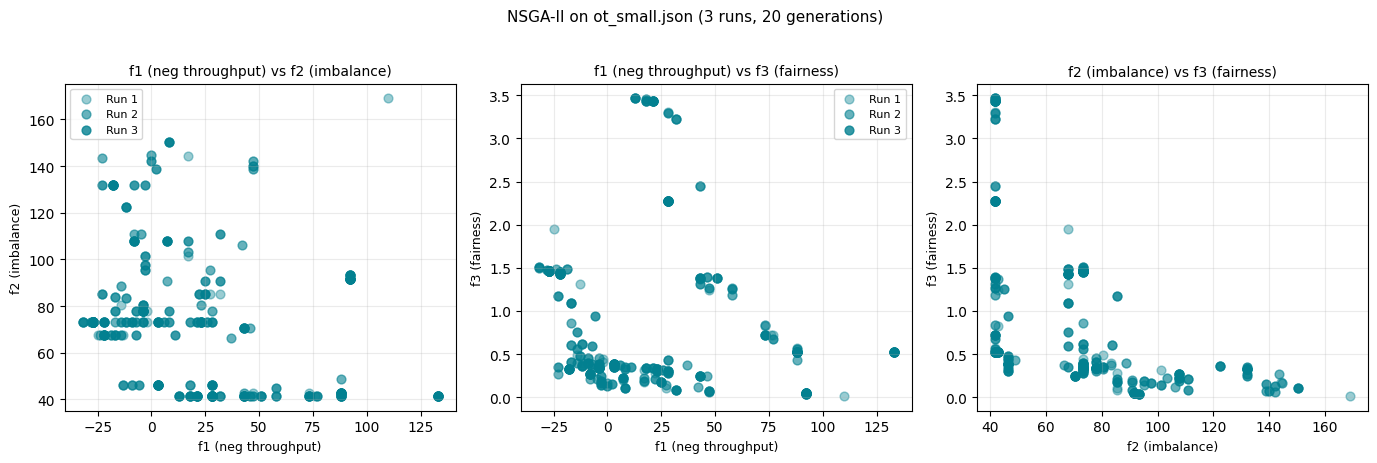

The f1 vs f2 plot shows the core trade-off:
  More surgeries done (f1 more negative) -> more resource pressure (f2 higher)


In [4]:
if result_files:
    # Load all runs
    all_fronts = []
    for path in result_files:
        with open(path) as f: d = json.load(f)
        all_fronts.append(np.array(d['F']))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    pairs = [(0,1,'f1 (neg throughput)','f2 (imbalance)'),
             (0,2,'f1 (neg throughput)','f3 (fairness)'),
             (1,2,'f2 (imbalance)',     'f3 (fairness)')]

    for ax, (xi, yi, xlabel, ylabel) in zip(axes, pairs):
        for i, F in enumerate(all_fronts):
            ax.scatter(F[:,xi], F[:,yi], c=TEAL, s=40,
                       alpha=0.4+i*0.2, label=f'Run {i+1}' if xi==0 else None)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{xlabel} vs {ylabel}', fontsize=10)
        ax.grid(alpha=0.25)
        if xi == 0: ax.legend(fontsize=8)

    plt.suptitle('NSGA-II on ot_small.json (3 runs, 20 generations)',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print('The f1 vs f2 plot shows the core trade-off:')
    print('  More surgeries done (f1 more negative) -> more resource pressure (f2 higher)')


---
## Part 3 - Compute quality indicators

In [6]:
from pymoo.indicators.hv import HV

if result_files:
    all_F     = np.vstack(all_fronts)
    ref_point = all_F.max(axis=0) * 1.1   # 10% worse than worst seen
    hv_calc   = HV(ref_point=ref_point)

    print(f'Reference point (for HV): {np.round(ref_point, 1)}')
    print()
    print(f"{'Run':>5}  {'HV':>14}  {'Spread':>10}  {'Front size':>10}")
    print('-' * 48)

    hvs, spreads = [], []
    for i, F in enumerate(all_fronts):
        hv  = float(hv_calc(F))
        sp  = float(np.sum(F.max(axis=0)-F.min(axis=0)))
        hvs.append(hv); spreads.append(sp)
        print(f'{i+1:>5}  {hv:>14.2f}  {sp:>10.2f}  {len(F):>10}')

    print()
    print(f'Mean HV:     {np.mean(hvs):.2f} +/- {np.std(hvs):.2f}')
    print(f'Mean spread: {np.mean(spreads):.2f} +/- {np.std(spreads):.2f}')
    print()
    print('For your coursework submission you need 30 runs of each configuration.')
    print('These 3 runs give you a rough idea but are not statistically meaningful yet.')


Reference point (for HV): [146.3 185.9   3.8]

  Run              HV      Spread  Front size
------------------------------------------------
    1        87556.36      272.92         100
    2        87687.67      270.34         100
    3        86607.23      273.17         100

Mean HV:     87283.76 +/- 481.37
Mean spread: 272.14 +/- 1.28

For your coursework submission you need 30 runs of each configuration.
These 3 runs give you a rough idea but are not statistically meaningful yet.


---
## Part 4 - Run NSGA-II from Python

In [7]:
from cio.algorithms import build_nsga2
from cio.problem import Instance, OTSchedulingProblem
from pymoo.optimize import minimize

inst    = Instance.from_json('instances/ot_small.json')
problem = OTSchedulingProblem(inst)

print(inst)
print(f'  Surgeries: {inst.n_surgeries}')
print(f'  OTs: {inst.n_ots},  Teams: {inst.n_teams},  Horizon: {inst.horizon_days} days')


Instance(name='small', horizon=7, n_surgeries=22, n_ots=2, n_teams=3)
  Surgeries: 22
  OTs: 2,  Teams: 3,  Horizon: 7 days


In [8]:
# Run NSGA-II - same as the CLI but from Python
algo = build_nsga2(pop_size=50, seed=42)
res  = minimize(problem, algo, ('n_gen', 20), seed=42, verbose=False)

print(f'Result: {len(res.F)} solutions on Pareto front')
print(f'res.F shape: {res.F.shape}  (solutions x objectives)')
print(f'res.X shape: {res.X.shape}  (solutions x surgery indices)')
print()
print('Best f1 (most surgeries):', res.F[:,0].min())
print('Best f2 (least imbalance):', res.F[:,1].min())


Result: 50 solutions on Pareto front
res.F shape: (50, 3)  (solutions x objectives)
res.X shape: (50, 22)  (solutions x surgery indices)

Best f1 (most surgeries): -32.0
Best f2 (least imbalance): 41.5


---
## Part 5 - Compare two crossover operators

In [9]:
from cio.operators import PMXCrossover, OrderCrossover, SwapMutation

print('Comparing PMX vs OX crossover (same everything else)...')
print()

configs = [
    ('PMX crossover (default)', PMXCrossover()),
    ('OX crossover',            OrderCrossover()),
]

all_F_compare = {}
for name, cx in configs:
    t0   = time.time()
    algo = build_nsga2(pop_size=50, crossover=cx, seed=42)
    res  = minimize(problem, algo, ('n_gen', 30), seed=42, verbose=False)
    rt   = time.time()-t0
    all_F_compare[name] = res.F
    print(f'{name:<30}: {len(res.F)} solutions,  time={rt:.1f}s')

print()
print('This is your first controlled experiment.')
print('Same seed, same generations, same instance - only the crossover changed.')


Comparing PMX vs OX crossover (same everything else)...

PMX crossover (default)       : 45 solutions,  time=0.9s
OX crossover                  : 50 solutions,  time=0.7s

This is your first controlled experiment.
Same seed, same generations, same instance - only the crossover changed.


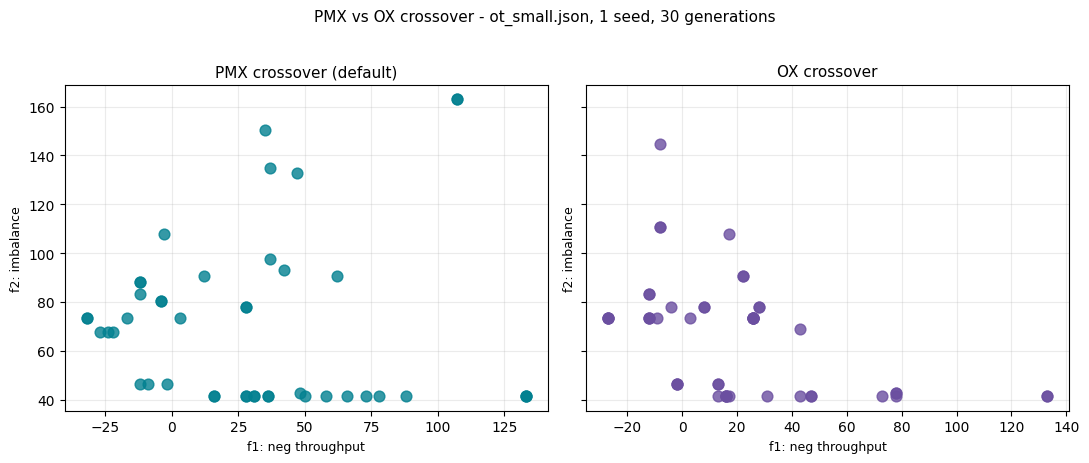

Are the fronts clearly different?
This single-seed comparison is illustrative only.
For a valid conclusion you need 30 seeds + Friedman test.


In [10]:
# Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, ((name, F), col) in zip(axes, zip(all_F_compare.items(), [TEAL, PURPLE])):
    if F is not None:
        ax.scatter(F[:,0], F[:,1], c=col, s=60, alpha=0.8, zorder=3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('f1: neg throughput', fontsize=9)
    ax.set_ylabel('f2: imbalance', fontsize=9)
    ax.grid(alpha=0.25)

plt.suptitle('PMX vs OX crossover - ot_small.json, 1 seed, 30 generations',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Are the fronts clearly different?')
print('This single-seed comparison is illustrative only.')
print('For a valid conclusion you need 30 seeds + Friedman test.')


---
## Part 6 - Design your first novel component

**Take 10 minutes.** Edit the stub in the cell below.
Click inside the cell and start typing. Run it with Shift+Enter to check validity.
It does not need to be finished or perfect today.

**Ideas for problem-tailored components:**
- Crossover that copies urgent (priority 4-5) surgeries from parent A, fills the rest from parent B in order
- Mutation that swaps a surgery in the second half with the closest-priority surgery in the first half
- Decoder that re-sorts by priority before placing (overrides permutation order for urgent cases)
- Initialiser that puts priority-5 patients in the first quarter of every initial permutation


In [11]:
class GraphGuidedCrossover:
    """
    Graph-Guided Crossover for Operating Theatre Scheduling.

    Idea:
    Preserve groups of surgeries that have strong resource relationships.

    Hospital knowledge used:
    - shared surgical team conflicts
    - shared OT/equipment conflicts
    - downstream ICU/ward resource pressure

    Expected improvement:
    - lower infeasible schedules
    - better resource utilisation balance (f2)
    - better throughput (f1)
    """

    def __init__(self, conflict_graph):
        self.conflict_graph = conflict_graph


    def __call__(
        self,
        parent_a: np.ndarray,
        parent_b: np.ndarray,
        rng
    ) -> tuple:


        size = len(parent_a)


        # ----------------------------------
        # 1. Select conflict-aware region
        # ----------------------------------

        start = rng.integers(0, size)
        length = rng.integers(
            max(2, size//5),
            max(3, size//2)
        )

        end = min(start + length, size)


        selected = parent_a[start:end]


        # ----------------------------------
        # 2. Expand using conflict graph
        # ----------------------------------

        graph_nodes = set(selected.tolist())


        for node in list(graph_nodes):

            if node in self.conflict_graph:

                neighbours = list(
                    self.conflict_graph[node]
                )

                # Add conflicting surgeries
                if len(neighbours) > 0:

                    chosen = rng.choice(
                        neighbours
                    )

                    graph_nodes.add(chosen)


        graph_nodes = list(graph_nodes)



        # ----------------------------------
        # 3. Create children
        # ----------------------------------

        child1 = self._insert_preserving_order(
            graph_nodes,
            parent_a,
            parent_b
        )

        child2 = self._insert_preserving_order(
            graph_nodes,
            parent_b,
            parent_a
        )


        return child1, child2



    def _insert_preserving_order(
        self,
        preserved,
        primary,
        secondary
    ):

        child = []


        # Keep graph-related surgeries first
        for x in primary:

            if x in preserved:
                child.append(x)


        # Fill remaining positions
        for x in secondary:

            if x not in child:
                child.append(x)


        return np.array(child)

---
## Before the next session

### This week - 5 tasks

**1. Run all three baselines** - paste each into the VS Code Terminal:
```
python scripts/run.py --config configs/nsga2_baseline.yaml --instance instances/ot_small.json --out results/nsga2_small/ --n-runs 3
python scripts/run.py --config configs/moead_baseline.yaml --instance instances/ot_small.json --out results/moead_small/ --n-runs 3
python scripts/run.py --config configs/pls_baseline.yaml   --instance instances/ot_small.json --out results/pls_small/   --n-runs 3
```

**2. Plot all three fronts** - in this notebook, change `results/first_run/` in
Part 1 to each folder above and re-run Parts 1-3 for each baseline.

**3. Read two files** - in the VS Code Explorer panel, open:
- `cio/problem/decoder.py` - read what `GreedyDecoder.__call__` does step by step
- `cio/operators/operators.py` - read what `BaseCrossover` looks like
Tip: Ctrl+Click any class name in VS Code to jump straight to its definition.

**4. Write one paragraph** describing your novel component idea.
What hospital knowledge does it use? What objective do you expect it to improve?

**5. Verify your install** - in the VS Code Terminal:
```
PYTHONPATH=. pytest tests/ -q
```
Should say 49 passed. If not, bring it to the next session.

---

### Quick reference for VS Code

| Task | How |
|------|-----|
| Run a baseline | VS Code Terminal: `python scripts/run.py --config configs/X.yaml --instance instances/ot_Y.json --out results/Z/` |
| Open a result file | Explorer panel -> results folder -> click any `run_*.json` |
| Open a source file | Explorer panel -> click any `.py` file |
| Jump to class definition | Ctrl+Click the class name in any `.py` file |
| Run a notebook cell | Click the cell, press Shift+Enter |
| Run all cells | Click 'Run All' button at the top of the notebook |
| Switch Python interpreter | Click the interpreter name in the bottom status bar |
| Open new terminal | Menu -> Terminal -> New Terminal |
| Check tests | VS Code Terminal: `PYTHONPATH=. pytest tests/ -q` |
